In [44]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setting up visualization style
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

# Load data set
df = pd.read_csv('retail_sales.csv')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [46]:
df.isnull().sum()

Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

In [47]:
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1825 non-null   object 
 2   Sales     1825 non-null   float64
 3   Quantity  1825 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1825 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [49]:
df['Date'] = pd.to_datetime(df['Date'])

In [50]:
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

In [51]:
numeric_cols = ['Sales','Quantity','Profit']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

In [52]:
df['Sales'].sum()

np.float64(1789415.370708221)

In [53]:
df.groupby("Category")["Sales"].sum()

Category
Books          370971.872558
Clothing       355420.126737
Electronics    365088.131422
Home Goods     347493.827088
NaN?              828.585950
Nan               823.190573
Null             1106.847949
Sports         347682.788431
Name: Sales, dtype: float64

In [54]:
df.groupby("Region")["Sales"].sum()

Region
East     394439.339642
Nan        1716.710787
North    449292.758063
South    473452.192387
West     470514.369828
Name: Sales, dtype: float64

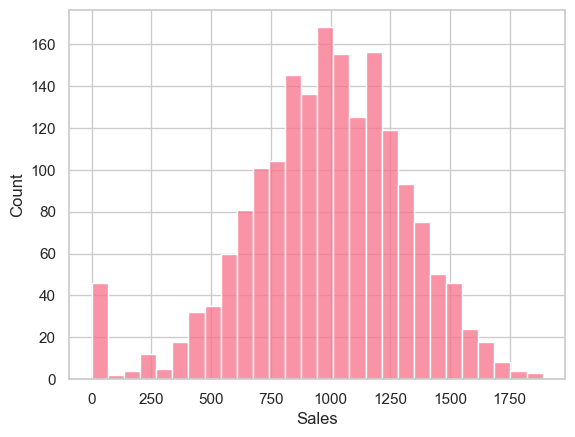

In [55]:
sns.histplot(
    df['Sales']
)
plt.show()

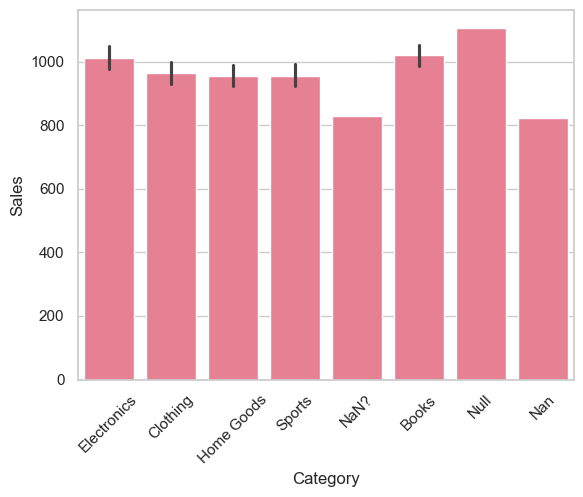

In [56]:
sns.barplot(
    x = 'Category',
    y = 'Sales',
    data = df
)
plt.xticks(rotation = 45)
plt.show()

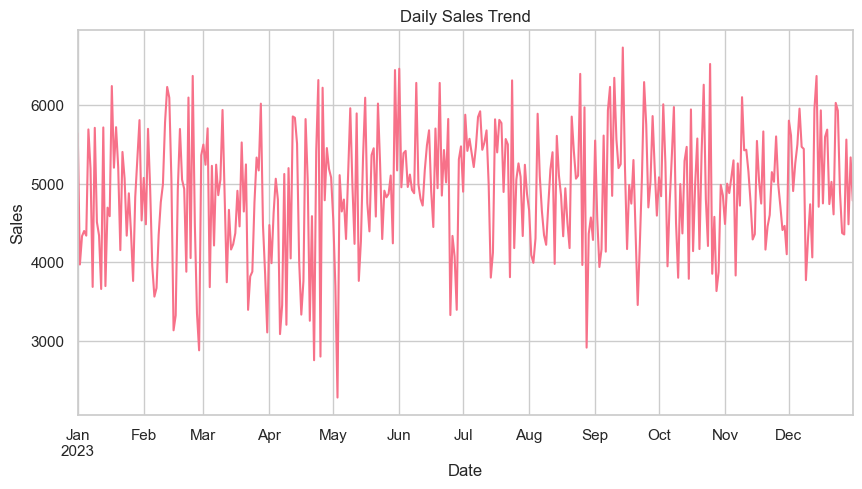

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
df.groupby("Date")["Sales"].sum().plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

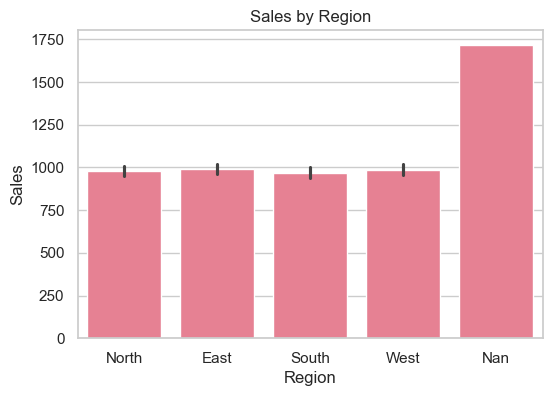

In [58]:
plt.figure(figsize=(6,4))
sns.barplot(x="Region", y="Sales", data=df)
plt.title("Sales by Region")
plt.show()

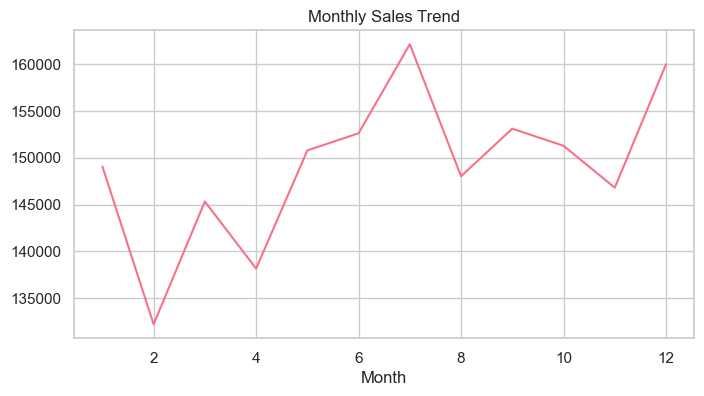

In [59]:
plt.figure(figsize = (8,4))
df.groupby('Month')['Sales'].sum().plot(kind = 'line')
plt.title("Monthly Sales Trend")
plt.show()

In [60]:
features = ['Quantity', 'Profit', 'Month', 'Quarter']
X = df[features]
y = df['Sales']

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 45
)


In [62]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [63]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha = 0.1)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

In [64]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [65]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [67]:
print("=== Lasso Regression ===")

y_pred_lasso = lasso.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))

=== Lasso Regression ===
MSE: 83390.73014939019
RMSE: 288.77453168413274
R2: 0.2860162833148153


In [68]:
print("=== ElasticNet Regression ===")

y_pred_elastic = elastic.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))
print("R2:", r2_score(y_test, y_pred_elastic))

=== ElasticNet Regression ===
MSE: 83269.91470467235
RMSE: 288.5652694013477
R2: 0.2870506939753059


In [69]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("=== Polynomial Regression ===")

print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("R2:", r2_score(y_test, y_pred_poly))

=== Polynomial Regression ===
MSE: 83616.64249035112
RMSE: 289.16542409207767
R2: 0.28408204275168103
